In [2]:
from load_sim_data import *
from load_shp import *
from sim_eval_pkg import *

Updated on 2026-03-04


In [3]:
param_datasets=[diff_em_roof,diff_em_improad,diff_em_perroad,diff_em_wall,
          diff_alb_roof,diff_alb_improad,diff_alb_perroad,diff_alb_wall,
         diff_wt_roof,diff_wt_perv,diff_ht_roof,diff_hwr]
meteo_vars=['TSKIN_U','TSA_U','RH2M_U','FSH_U','EFLX_LH_TOT_U','FIRA_U','FSA_U','Residual_U']
meteo_desc_vars=['Land surface T','2m T','2m RH','Sensible heat','Latent heat','Net infrared','Net solar','Residual']
row_names=[rf'$\Delta$ {v}' for v in meteo_desc_vars]
var_desc = ['Roof $e$', 'Impervious $e$', 'Pervious $e$', 'Wall $e$', 
            'Roof $\\alpha$', 'Impervious $\\alpha$', 'Pervious $\\alpha$', 'Wall $\\alpha$',
            'Roof frac', 'Pervious frac', 'Roof $H$', 'Canyon $H/W$']
xticklabels = [rf'$\Delta$ {v}' for v in var_desc]

In [8]:
def build_Xy_from_vectors(y_vec, param_datasets):
    y = np.asarray(y_vec).reshape(-1)
    X_cols = []
    
    for x in param_datasets:
        x = np.asarray(x).reshape(-1)
        X_cols.append(x)

    X = np.column_stack(X_cols)  
    m = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    Xc = X[m, :]
    yc = y[m]
    return Xc, yc, m

def fit_multivar_linear(X, y, standardize=True):
    if standardize:
        sx = StandardScaler(with_mean=True, with_std=True)
        sy = StandardScaler(with_mean=True, with_std=True)
        Xs = sx.fit_transform(X)
        ys = sy.fit_transform(y.reshape(-1, 1)).ravel()

        model = LinearRegression(fit_intercept=True)
        model.fit(Xs, ys)
        yhat = model.predict(Xs)
        r2 = r2_score(ys, yhat)

        beta = model.coef_.copy()          
        intercept = model.intercept_
        return model, yhat, r2, beta, intercept, sx, sy

    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)
    yhat = model.predict(X)
    r2 = r2_score(y, yhat)
    beta = model.coef_.copy()
    intercept = model.intercept_
    return model, yhat, r2, beta, intercept, None, None

def shapley_r2_linear(X, y, n_perm=2000, random_state=0):
    rng = np.random.default_rng(random_state)
    n, p = X.shape
    
    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)
    total_r2 = r2_score(y, model.predict(X))

    phi = np.zeros(p, dtype=float)

    for _ in range(n_perm):
        order = rng.permutation(p)
        used = []
        prev_r2 = 0.0

        for j in order:
            used.append(j)
            X_sub = X[:, used]

            model.fit(X_sub, y)
            cur_r2 = r2_score(y, model.predict(X_sub))

            phi[j] += (cur_r2 - prev_r2)
            prev_r2 = cur_r2

    phi /= float(n_perm)
    
    if np.isfinite(total_r2) and np.isfinite(phi).all() and phi.sum() != 0:
        phi = phi * (total_r2 / phi.sum())

    return phi, total_r2

In [7]:
def extract_conus_model_var_diff_multivar(var, param_datasets, standardize=True,
                                          n_perm=2000, random_state=0):
    conus_ctrl = clip_netcdf_by_shp(ctrl_annual_avg_1d32deg[var], us_clusters_bounds)
    conus_test = clip_netcdf_by_shp(test_annual_avg_1d32deg[var], us_clusters_bounds)

    valid_mask = np.isfinite(conus_ctrl) & np.isfinite(conus_test)
    conus_ctrl = conus_ctrl.where(valid_mask)
    conus_test = conus_test.where(valid_mask)

    ctrl = conus_ctrl.values.flatten()
    test = conus_test.values.flatten()

    flat_valid_mask = np.isfinite(ctrl) & np.isfinite(test)
    ctrl_clean = ctrl[flat_valid_mask]
    test_clean = test[flat_valid_mask]

    y = test_clean - ctrl_clean 

    X, y2, m = build_Xy_from_vectors(y, param_datasets)

    model, yhat, r2, beta, intercept, sx, sy = fit_multivar_linear(X, y2, standardize=standardize)

    if standardize:
        X_for_shap = sx.transform(X)
        y_for_shap = sy.transform(y2.reshape(-1, 1)).ravel()
    else:
        X_for_shap = X
        y_for_shap = y2

    phi, total_r2 = shapley_r2_linear(X_for_shap, y_for_shap,
                                      n_perm=n_perm, random_state=random_state)

    return {
        "beta": beta,                
        "intercept": intercept,
        "r2": r2,
        "shapley_r2": phi,            
        "total_r2": total_r2,
        "n": X.shape[0]
    }

In [10]:
def calculate_residual_energy(ds):
    ds['Residual_U']=ds['FIRA_U']+ds['FSA_U']-ds['EFLX_LH_TOT_U']-ds['FSH_U']
    return ds

In [11]:
ctrl_annual_avg_1d32deg=calculate_residual_energy(ctrl_annual_avg_1d32deg)
test_annual_avg_1d32deg=calculate_residual_energy(test_annual_avg_1d32deg)

In [54]:
BETA_list = []
PHI_list = []
R2_list = []
N_list = []

for k, var in enumerate(meteo_vars):
    out = extract_conus_model_var_diff_multivar(
        var,
        param_datasets=param_datasets,
        standardize=True,         
        n_perm=3000,            
        random_state=42 + k)

    BETA_list.append(out["beta"].reshape(-1))          
    PHI_list.append(out["shapley_r2"].reshape(-1))     
    R2_list.append(out["total_r2"])
    N_list.append(out["n"])

BETA = np.asarray(BETA_list)   
PHI  = np.asarray(PHI_list)    
R2_total = np.asarray(R2_list) 
N_eff = np.asarray(N_list)     

In [56]:
# np.save("multivariate_BETA_5yr_annual.npy", BETA)
# np.save("multivariate_PHI_5yr_annual.npy", PHI)
# np.save("multivariate_R2_5yr_annual.npy", R2_total)
# np.save("multivariate_N_eff_5yr_annual.npy", N_eff)

In [18]:
BETA=np.load("multivariate_BETA_5yr_annual.npy")
PHI=np.load("multivariate_PHI_5yr_annual.npy")
R2_total=np.load("multivariate_R2_5yr_annual.npy")
N_eff=np.load("multivariate_N_eff_5yr_annual.npy")        

___

### Fig 9a

___

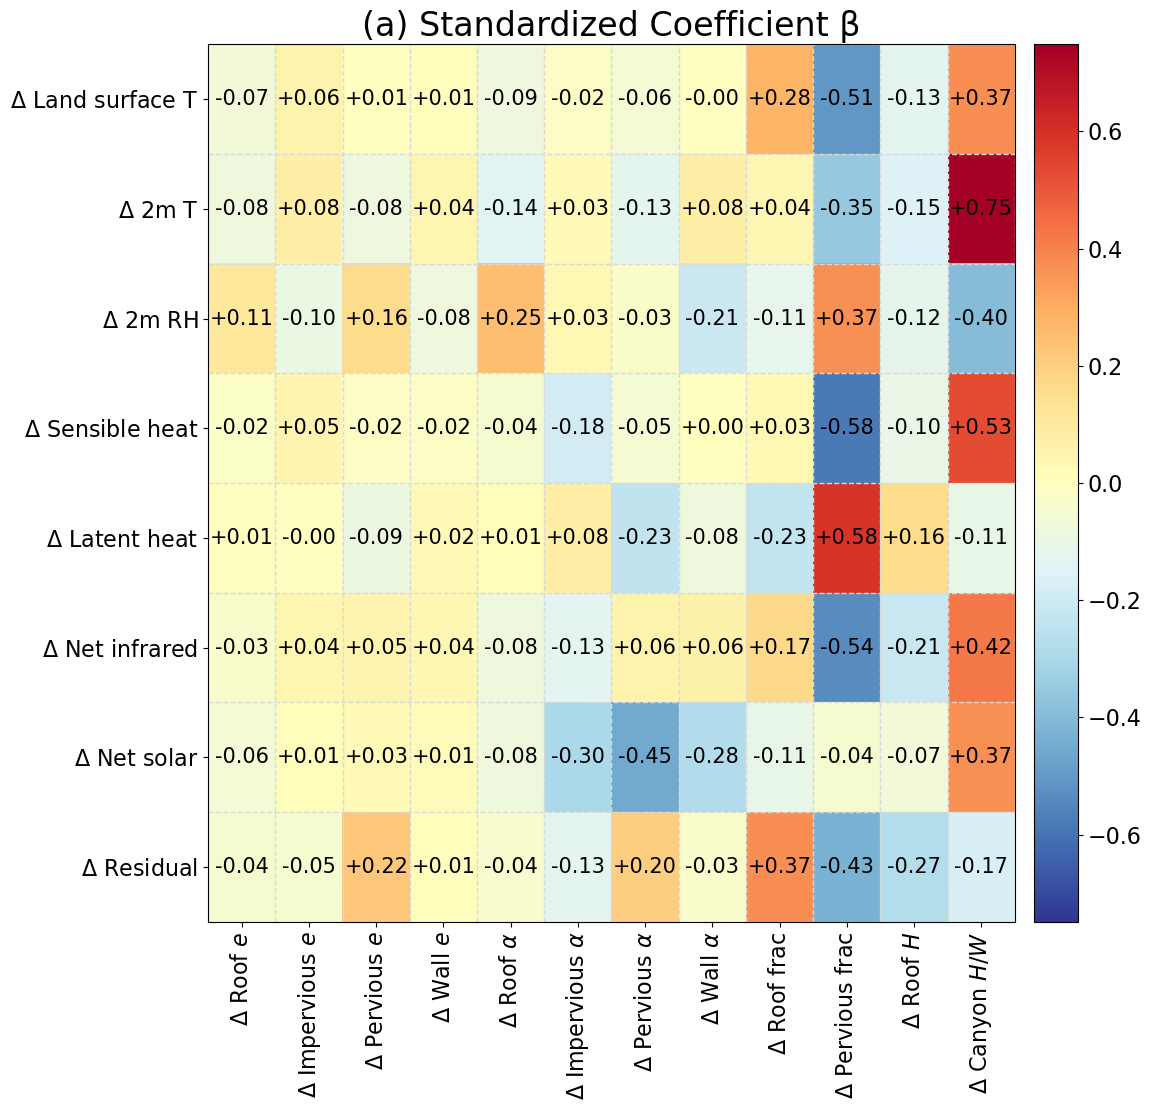

In [22]:
BETA = np.asarray(BETA)
PHI = np.asarray(PHI)
R2_total = np.asarray(R2_total)
N_eff = np.asarray(N_eff)

nrow, ncol = BETA.shape

figA, axA = plt.subplots(figsize=(12, 1.2 * nrow + 1.6))

vmax = np.nanmax(np.abs(BETA))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 1.0

imA = axA.imshow(
    BETA,
    aspect="auto",
    cmap="RdYlBu_r",
    norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax),
)

for i in range(nrow):
    for j in range(ncol):
        val = BETA[i, j]
        if np.isfinite(val):
            axA.text(j, i, f"{val:+.2f}", ha="center", va="center", fontsize=15)

axA.set_xlim(-0.5, ncol - 0.5)
axA.set_ylim(nrow - 0.5, -0.5)

axA.set_yticks(np.arange(nrow))
axA.set_yticklabels(row_names, fontsize=16)

axA.set_xticks(np.arange(ncol))
axA.set_xticklabels(xticklabels, rotation=90, fontsize=16)

axA.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
axA.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
axA.grid(which="minor", color="0.85", linewidth=1, linestyle="--")
axA.tick_params(which="minor", bottom=False, left=False)

cbarA = figA.colorbar(imA, ax=axA, pad=0.02)
cbarA.ax.tick_params(labelsize=16)
axA.set_title("(a) Standardized Coefficient β", fontsize=24)

plt.tight_layout()

___

### Fig 9b

___

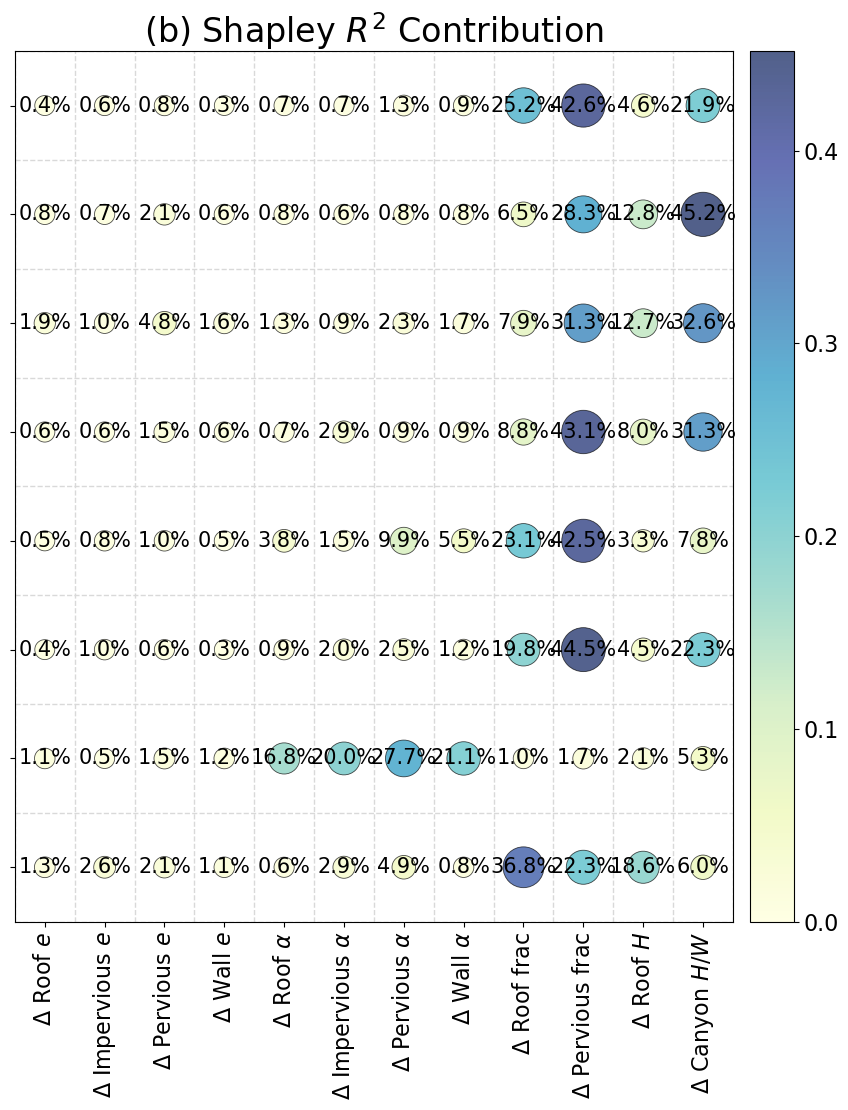

In [23]:
PHI_frac = np.zeros_like(PHI, dtype=float)
m = np.isfinite(R2_total) & (R2_total > 0)
PHI_frac[m, :] = PHI[m, :] / R2_total[m, None]
PHI_frac[~np.isfinite(PHI_frac)] = np.nan

figB, axB = plt.subplots(figsize=(9, 1.2 * nrow + 1.6))

xx, yy = np.meshgrid(np.arange(ncol), np.arange(nrow))

smin, smax = 200, 2000
S = smin + (smax - smin) * np.nan_to_num(PHI_frac, nan=0.0)

scB = axB.scatter(
    xx.ravel(), yy.ravel(),
    s=S.ravel(),
    c=PHI_frac.ravel(),
    cmap="YlGnBu",
    vmin=0.0,
    vmax=np.nanmax(PHI_frac) if np.isfinite(np.nanmax(PHI_frac)) else 1.0,
    edgecolors="k",
    linewidths=0.6,
    alpha=0.7
)

for i in range(nrow):
    for j in range(ncol):
        val = PHI_frac[i, j]
        if np.isfinite(val):
            axB.text(j, i, f"{100*val:.1f}%", ha="center", va="center", fontsize=15)

axB.set_xlim(-0.5, ncol - 0.5)
axB.set_ylim(nrow - 0.5, -0.5)

axB.set_yticks(np.arange(nrow))
axB.set_yticklabels([])

axB.set_xticks(np.arange(ncol))
axB.set_xticklabels(xticklabels, rotation=90, fontsize=16)

axB.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
axB.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
axB.grid(which="minor", color="0.85", linewidth=1, linestyle="--")
axB.tick_params(which="minor", bottom=False, left=False)

cbarB = figB.colorbar(scB, ax=axB, pad=0.02)
cbarB.ax.tick_params(labelsize=16)
axB.set_title("(b) Shapley $R^2$ Contribution", fontsize=24)

plt.tight_layout()

___

### Fig 9c

___

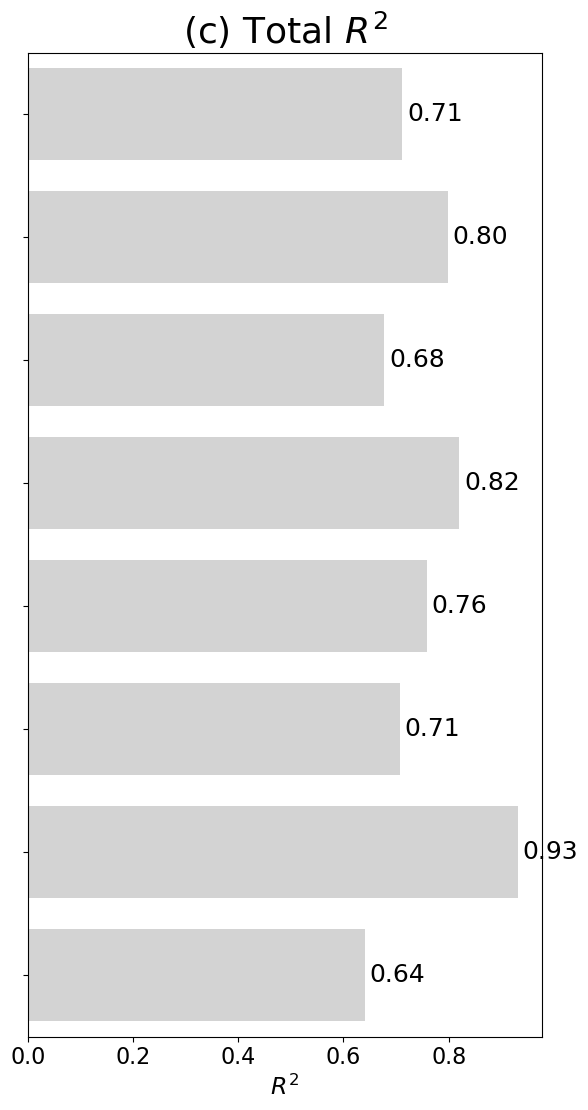

In [24]:
figC, axC = plt.subplots(figsize=(6, 1.2 * nrow + 1.6))

ypos = np.arange(nrow)
axC.barh(ypos, R2_total, height=0.75, color='lightgray')

axC.set_ylim(nrow - 0.5, -0.5)
axC.set_yticks(np.arange(nrow))
axC.set_yticklabels([])
axC.set_xlabel("$R^2$", fontsize=17)
axC.tick_params(axis="x", labelsize=16)
r2max = np.nanmax(R2_total) if np.isfinite(np.nanmax(R2_total)) else 1.0
pad = 0.01 * r2max

for i in range(nrow):
    r2 = R2_total[i]
    n_eff = N_eff[i]
    if np.isfinite(r2):
        txt = f"{r2:.2f}"
        axC.text(r2 + pad, i, txt, va="center", fontsize=18)
axC.set_title("(c) Total $R^2$", fontsize=26)

plt.tight_layout()